In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


λ = -0.5 -> Equilibrios: [(0.0, 0.0)]


C:\Users\Lucas\AppData\Local\Temp\ipykernel_13500\2568877209.py:4: RuntimeWarning: overflow encountered in scalar multiply
  dYdt = -x - l * (x**2-1) * y
C:\Users\Lucas\AppData\Local\Temp\ipykernel_13500\2568877209.py:4: RuntimeWarning: overflow encountered in scalar power
  dYdt = -x - l * (x**2-1) * y
C:\Users\Lucas\AppData\Local\Temp\ipykernel_13500\2568877209.py:4: RuntimeWarning: invalid value encountered in scalar subtract
  dYdt = -x - l * (x**2-1) * y


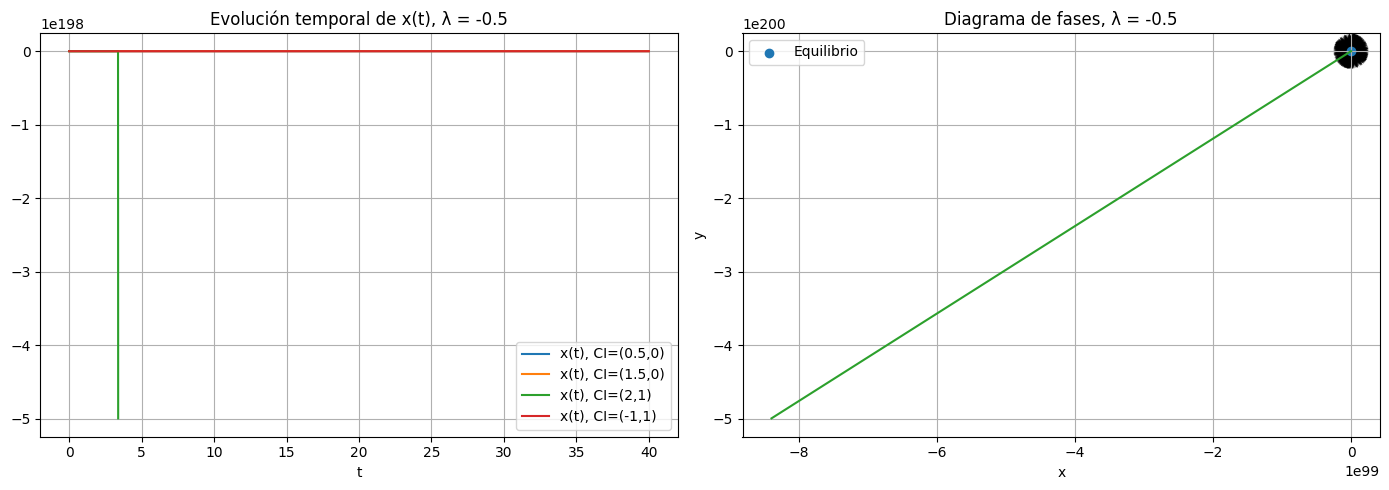

λ = 0 -> Equilibrios: [(0.0, 0.0)]


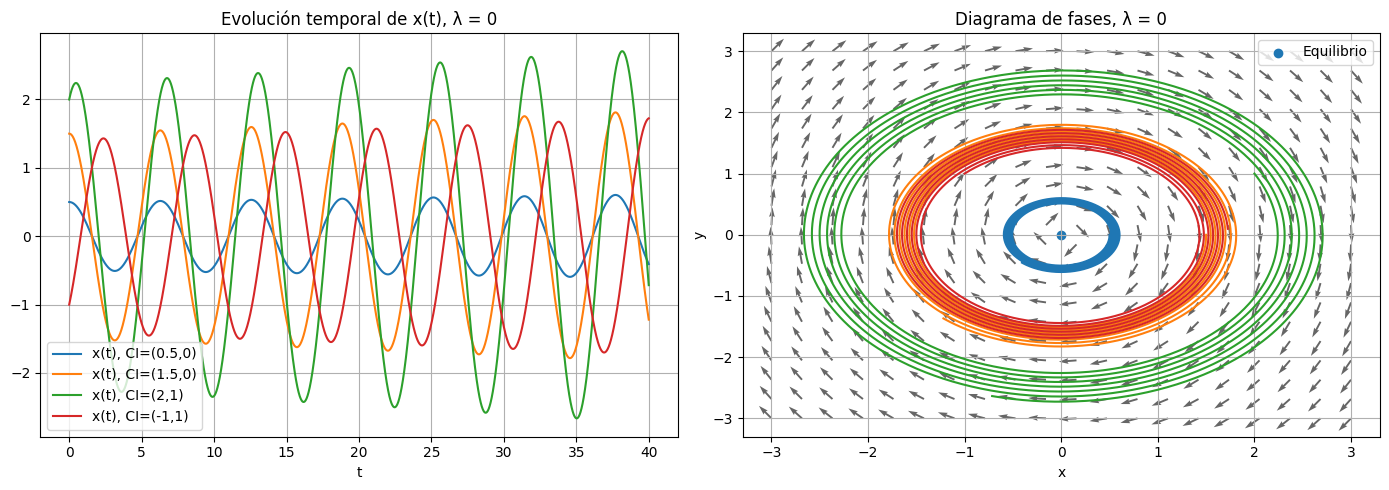

λ = 0.5 -> Equilibrios: [(0.0, 0.0)]


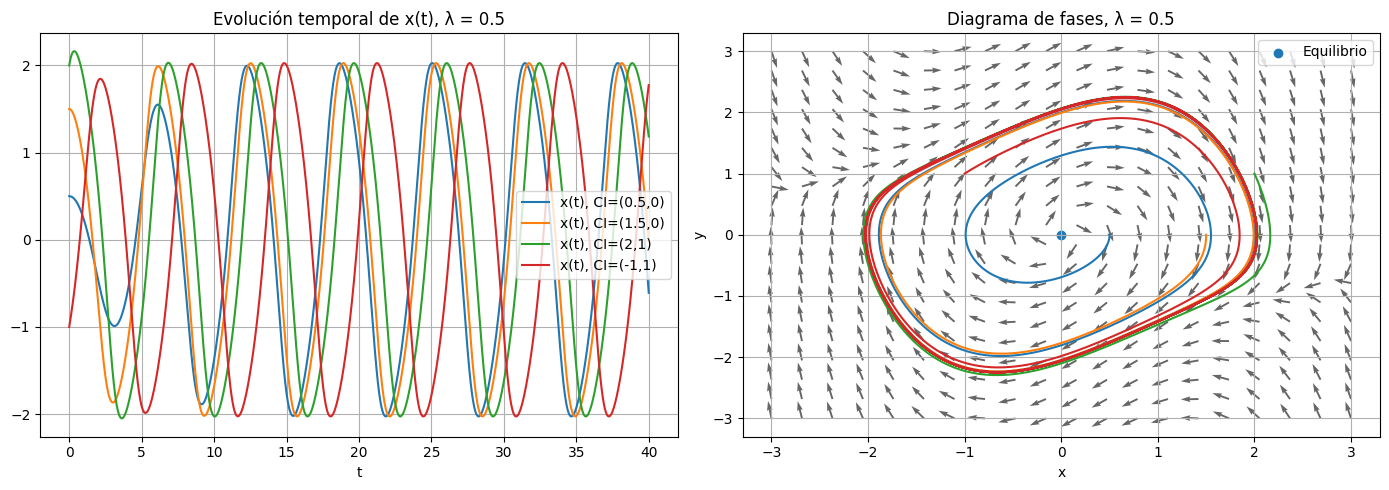

In [17]:
def sistema(estado, l):
    x, y = estado
    dXdt = y
    dYdt = -x - l * (x**2-1) * y
    return np.array([dXdt,dYdt])

def euler(x0, y0, l, t0, tf, h):
    num_pasos = int((tf-t0)/h)
    t = np.linspace(t0, tf, num_pasos+1)
    
    X = np.zeros(num_pasos+1)
    X[0] = x0
    Y = np.zeros(num_pasos+1)
    Y[0] = y0 
    
    for i in range(num_pasos):
        estado = np.array([X[i], Y[i]])
        pendiente = sistema(estado, l)
        
        X[i+1] = X[i] + h * pendiente[0]
        Y[i+1] = Y[i] + h * pendiente[1]
        
    return t, X, Y


lambdas = [-0.5, 0, 0.5]
condiciones_iniciales = [(0.5, 0), (1.5, 0), (2, 1), (-1, 1)]
for lam in lambdas:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Equilibrio
    X_sym, Y_sym = sp.symbols('X Y')
    l_sym = sp.symbols('l')

    eq1 = Y_sym
    eq2 = -X_sym - l_sym * (X_sym**2 - 1) * Y_sym

    equilibrios = sp.solve((eq1, eq2), (X_sym, Y_sym))
    valores = {l_sym: lam}
    equilibrios_num = [(float(x.subs(valores)), float(y.subs(valores))) for x, y in equilibrios]
    print(f"λ = {lam} -> Equilibrios: {equilibrios_num}")


    # Campo vectorial
    x_vals = np.linspace(-3, 3, 20)
    y_vals = np.linspace(-3, 3, 20)
    X_grid, Y_grid = np.meshgrid(x_vals, y_vals)

    U = Y_grid
    V = -X_grid - lam * (X_grid**2 - 1) * Y_grid

    norma = np.sqrt(U**2 + V**2)
    norma[norma == 0] = 1

    U_norm = U / norma
    V_norm = V / norma

    axes[1].quiver(X_grid, Y_grid, U_norm, V_norm, alpha=0.6)

    # Trayectorias
    for x0, y0 in condiciones_iniciales:
        t, x, y = euler(x0, y0, lam, 0, 40, 0.01)

        axes[0].plot(t, x, label=f'x(t), CI=({x0},{y0})')
        axes[1].plot(x, y)

    axes[0].set_title(f'Evolución temporal de x(t), λ = {lam}')
    axes[0].set_xlabel('t')
    axes[0].grid(True)
    axes[0].legend()

    axes[1].scatter(0, 0, marker='o', label='Equilibrio')
    axes[1].set_title(f'Diagrama de fases, λ = {lam}')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].grid(True)
    axes[1].legend()

    plt.tight_layout()
    plt.show()